In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150

# current directory
base_dir = Path(".")

benchmark_file = base_dir / "benchmark_results_category.json"

output_dir = base_dir / "category_analysis_outputs"
output_dir.mkdir(exist_ok=True)

model_map = {
    "gemini_3.1_flash_lite_outputs": "Gemini 3.1 Flash Lite",
    "gemini_3.5_flash_outputs": "Gemini 3.5 Flash",
    "gpt54nano_outputs": "GPT-5.4 Nano",
    "gpt54minioutputs": "GPT-5.4 Mini",
    "DeepSeek_V4_Flash_outputs": "DeepSeek V4 Flash",
    "mistral_large_3_outputs": "Mistral Large 3"
}

model_folders = list(model_map.keys())

In [2]:
with open(benchmark_file, "r", encoding="utf-8") as f:
    benchmark = json.load(f)

print("Images:", len(benchmark))

Images: 350


In [3]:
def expand_panel(panel_label):

    s = (
        str(panel_label)
        .strip()
        .strip("()")
        .replace("–", "-")
        .replace("—", "-")
        .replace(" ", "")
    )

    if s.lower() == "main":
        return ["main"]

    panels = []

    for part in s.split(","):

        if "-" in part:

            start, end = part.split("-")

            if (
                len(start) == 1
                and len(end) == 1
                and start.isalpha()
                and end.isalpha()
            ):

                panels.extend(
                    [
                        chr(i)
                        for i in range(
                            ord(start.lower()),
                            ord(end.lower()) + 1
                        )
                    ]
                )

                continue

        panels.append(part.lower())

    return panels

In [4]:
prediction_rows = []

skipped_files = []

for model_folder in model_folders:

    folder = base_dir / model_folder
    json_files = list(folder.glob("*.json"))

    print(model_folder, len(json_files))

    for file in json_files:

        image_id = file.stem

        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # skip malformed outputs
        if "panels" not in data:
            skipped_files.append(file)
            continue

        if not isinstance(data["panels"], list):
            skipped_files.append(file)
            continue

        for panel_obj in data["panels"]:

            atomic_panels = expand_panel(
                panel_obj.get("panel", "main")
            )

            for p in atomic_panels:

                prediction_rows.append(
                    {
                        "image_id": image_id,
                        "model_raw": model_folder,
                        "model": model_map[model_folder],
                        "panel": p,
                        "pred_category":
                            panel_obj.get("visualization_category"),
                        "pred_subcategory":
                            panel_obj.get("visualization_subtype"),
                    }
                )

pred_df = pd.DataFrame(prediction_rows)

print("prediction rows:", len(pred_df))
print("skipped files:", len(skipped_files))

gemini_3.1_flash_lite_outputs 361
gemini_3.5_flash_outputs 361
gpt54nano_outputs 361
gpt54minioutputs 361
DeepSeek_V4_Flash_outputs 361
mistral_large_3_outputs 361
prediction rows: 11284
skipped files: 1


In [5]:
file = list((base_dir / "gpt54nano_outputs").glob("*.json"))[0]

with open(file) as f:
    data = json.load(f)

print(type(data))
print(data.keys() if isinstance(data, dict) else data[:2])

<class 'dict'>
dict_keys(['panels'])


In [6]:
benchmark_rows = []

for image_id, image_data in benchmark.items():

    category_benchmark = image_data.get("category_benchmark", {})

    for model_raw, panels in category_benchmark.items():

        for panel_label, values in panels.items():

            atomic_panels = expand_panel(panel_label)

            for p in atomic_panels:

                benchmark_rows.append(
                    {
                        "image_id": image_id,
                        "model_raw": model_raw,
                        "model": model_map.get(model_raw, model_raw),
                        "panel": p,
                        "category_correct":
                            values.get("category_correct"),
                        "subcategory_correct":
                            values.get("subtype_correct")
                    }
                )

bench_df = pd.DataFrame(benchmark_rows)

print(bench_df.shape)
bench_df.head()

(9132, 6)


,image_id,model_raw,model,panel,category_correct,subcategory_correct
0,img1106,gemini_3.1_flash_lite_outputs,Gemini 3.1 Flash Lite,main,False,False
1,img1106,gemini_3.5_flash_outputs,Gemini 3.5 Flash,main,False,False
2,img1106,gpt54nano_outputs,GPT-5.4 Nano,main,True,True
3,img1106,gpt54minioutputs,GPT-5.4 Mini,main,False,False
4,img1106,DeepSeek_V4_Flash_outputs,DeepSeek V4 Flash,main,False,False


In [7]:
merged_df = bench_df.merge(
    pred_df,
    on=["image_id", "model_raw", "model", "panel"],
    how="left"
)

print(merged_df.shape)

merged_df.head()

(9141, 8)


,image_id,model_raw,model,panel,category_correct,subcategory_correct,pred_category,pred_subcategory
0,img1106,gemini_3.1_flash_lite_outputs,Gemini 3.1 Flash Lite,main,False,False,Schematic/Diagram,Mechanism Diagram
1,img1106,gemini_3.5_flash_outputs,Gemini 3.5 Flash,main,False,False,Schematic/Diagram,Mechanism Diagram
2,img1106,gpt54nano_outputs,GPT-5.4 Nano,main,True,True,Generic Plot,Contour Plot
3,img1106,gpt54minioutputs,GPT-5.4 Mini,main,False,False,Schematic/Diagram,Flowchart
4,img1106,DeepSeek_V4_Flash_outputs,DeepSeek V4 Flash,main,False,False,Schematic/Diagram,Mechanism Diagram


In [8]:
true_category = {}
true_subcategory = {}

for (image_id, panel), group in merged_df.groupby(["image_id", "panel"]):

    # category
    cat_candidates = (
        group.loc[group["category_correct"] == True, "pred_category"]
        .dropna()
        .tolist()
    )

    if len(cat_candidates) > 0:
        true_category[(image_id, panel)] = Counter(
            cat_candidates
        ).most_common(1)[0][0]

    # subtype
    subtype_candidates = (
        group.loc[group["subcategory_correct"] == True,
                  "pred_subcategory"]
        .dropna()
        .tolist()
    )

    if len(subtype_candidates) > 0:
        true_subcategory[(image_id, panel)] = Counter(
            subtype_candidates
        ).most_common(1)[0][0]

In [9]:
merged_df["true_category"] = [
    true_category.get((r.image_id, r.panel))
    for r in merged_df.itertuples()
]

merged_df["true_subcategory"] = [
    true_subcategory.get((r.image_id, r.panel))
    for r in merged_df.itertuples()
]

merged_df.head()

,image_id,model_raw,model,panel,category_correct,subcategory_correct,pred_category,pred_subcategory,true_category,true_subcategory
0,img1106,gemini_3.1_flash_lite_outputs,Gemini 3.1 Flash Lite,main,False,False,Schematic/Diagram,Mechanism Diagram,Generic Plot,Contour Plot
1,img1106,gemini_3.5_flash_outputs,Gemini 3.5 Flash,main,False,False,Schematic/Diagram,Mechanism Diagram,Generic Plot,Contour Plot
2,img1106,gpt54nano_outputs,GPT-5.4 Nano,main,True,True,Generic Plot,Contour Plot,Generic Plot,Contour Plot
3,img1106,gpt54minioutputs,GPT-5.4 Mini,main,False,False,Schematic/Diagram,Flowchart,Generic Plot,Contour Plot
4,img1106,DeepSeek_V4_Flash_outputs,DeepSeek V4 Flash,main,False,False,Schematic/Diagram,Mechanism Diagram,Generic Plot,Contour Plot


In [10]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9141 entries, 0 to 9140
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   image_id             9141 non-null   str   
 1   model_raw            9141 non-null   str   
 2   model                9141 non-null   str   
 3   panel                9141 non-null   str   
 4   category_correct     9141 non-null   bool  
 5   subcategory_correct  9126 non-null   object
 6   pred_category        9141 non-null   str   
 7   pred_subcategory     9141 non-null   str   
 8   true_category        8681 non-null   str   
 9   true_subcategory     8609 non-null   str   
dtypes: bool(1), object(1), str(8)
memory usage: 1.4+ MB


In [11]:
merged_df.to_csv(output_dir / "category_predictions_benchmarks.csv", index=False)

In [12]:
truth_df = (
    merged_df[
        ["image_id",
         "panel",
         "true_category",
         "true_subcategory"]
    ]
    .drop_duplicates()
)

truth_df["true_category"].value_counts()

true_category
Generic Plot                 439
Microscopy                   303
Photograph                   149
Simulation                   129
Schematic/Diagram             96
Mechanical Test               91
Spectroscopy                  78
Diffraction                   47
Tomography/3D                 45
Thermal Analysis              45
Compositional Map             25
Machine Learning              12
Phase/Equilibrium Diagram      5
Electrochemistry               5
Magnetic/Electronic            1
Optical/Photonic               1
Name: count, dtype: int64

In [22]:
category_accuracy = (
    merged_df
    .dropna(subset=["true_category"])
    .groupby(
        ["model", "true_category"]
    )["category_correct"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

category_accuracy

true_category,Compositional Map,Diffraction,Electrochemistry,Generic Plot,Machine Learning,Magnetic/Electronic,Mechanical Test,Microscopy,Optical/Photonic,Phase/Equilibrium Diagram,Photograph,Schematic/Diagram,Simulation,Spectroscopy,Thermal Analysis,Tomography/3D
model,,,,,,,,,,,,,,,,
DeepSeek V4 Flash,100.0,89.36,80.0,92.58,83.33,100.0,80.90,98.67,100.0,40.0,87.25,90.53,64.00,96.15,100.00,93.33
GPT-5.4 Mini,88.0,100.00,80.0,73.41,75.00,100.0,75.28,92.69,100.0,80.0,83.11,82.61,76.80,98.72,100.00,95.56
GPT-5.4 Nano,96.0,93.62,80.0,75.89,100.00,100.0,66.29,95.96,100.0,40.0,43.24,88.04,55.65,96.15,97.73,86.67
Gemini 3.1 Flash Lite,96.0,95.74,100.0,79.67,83.33,100.0,86.52,98.32,100.0,100.0,88.51,92.63,94.40,98.72,97.67,93.33
Gemini 3.5 Flash,100.0,100.00,100.0,89.66,75.00,100.0,97.75,99.00,0.0,100.0,94.63,87.37,93.60,94.81,95.45,86.67
Mistral Large 3,100.0,93.62,100.0,84.33,83.33,0.0,76.40,92.67,100.0,80.0,88.51,93.68,80.00,96.15,97.92,82.22


In [23]:
truth_df = (
    merged_df[
        ["image_id", "panel", "true_category", "true_subcategory"]
    ]
    .drop_duplicates()
)

print(truth_df["true_subcategory"].value_counts(dropna=False).to_string())

print(truth_df["true_subcategory"].value_counts())

true_subcategory
Line Graph                    242
SEM                           224
FEA/FEM Result                127
Sample Photo                  119
Bar Chart                     112
NaN                            98
Optical Micrograph             51
Stress-Strain Curve            48
Process Schematic              41
Mechanism Diagram              41
XPS Spectrum                   38
Micro-CT                       36
DSC Curve                      34
Contour Plot                   28
Scatter Plot                   28
Fatigue/S-N Curve              26
EDS Map                        23
FTIR Spectrum                  23
In-situ Photo                  21
TEM                            18
Experimental Setup             17
EBSD Map                       14
XRD Pattern                    14
EDX Spectrum                   12
3D Reconstruction              11
Heatmap                        10
Equipment Photo                 9
Inverse Pole Figure             7
SAED                           

In [19]:
category_accuracy = (
    merged_df
    .dropna(subset=["true_subcategory"])
    .groupby(
        ["model", "true_subcategory"]
    )["subcategory_correct"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)



In [24]:
# Number of image-panels per true category
category_counts = (
    truth_df["true_category"]
    .value_counts()
)

category_counts


true_category
Generic Plot                 439
Microscopy                   303
Photograph                   149
Simulation                   129
Schematic/Diagram             96
Mechanical Test               91
Spectroscopy                  78
Diffraction                   47
Tomography/3D                 45
Thermal Analysis              45
Compositional Map             25
Machine Learning              12
Phase/Equilibrium Diagram      5
Electrochemistry               5
Magnetic/Electronic            1
Optical/Photonic               1
Name: count, dtype: int64

true_category          Generic Plot  Microscopy  Photograph  Simulation  \
model                                                                     
DeepSeek V4 Flash             92.58       98.67       87.25       64.00   
GPT-5.4 Mini                  73.41       92.69       83.11       76.80   
GPT-5.4 Nano                  75.89       95.96       43.24       55.65   
Gemini 3.1 Flash Lite         79.67       98.32       88.51       94.40   
Gemini 3.5 Flash              89.66       99.00       94.63       93.60   
Mistral Large 3               84.33       92.67       88.51       80.00   

true_category          Schematic/Diagram  Mechanical Test  Spectroscopy  \
model                                                                     
DeepSeek V4 Flash                  90.53            80.90         96.15   
GPT-5.4 Mini                       82.61            75.28         98.72   
GPT-5.4 Nano                       88.04            66.29         96.15   
Gemini 3.1 Flash Lite   

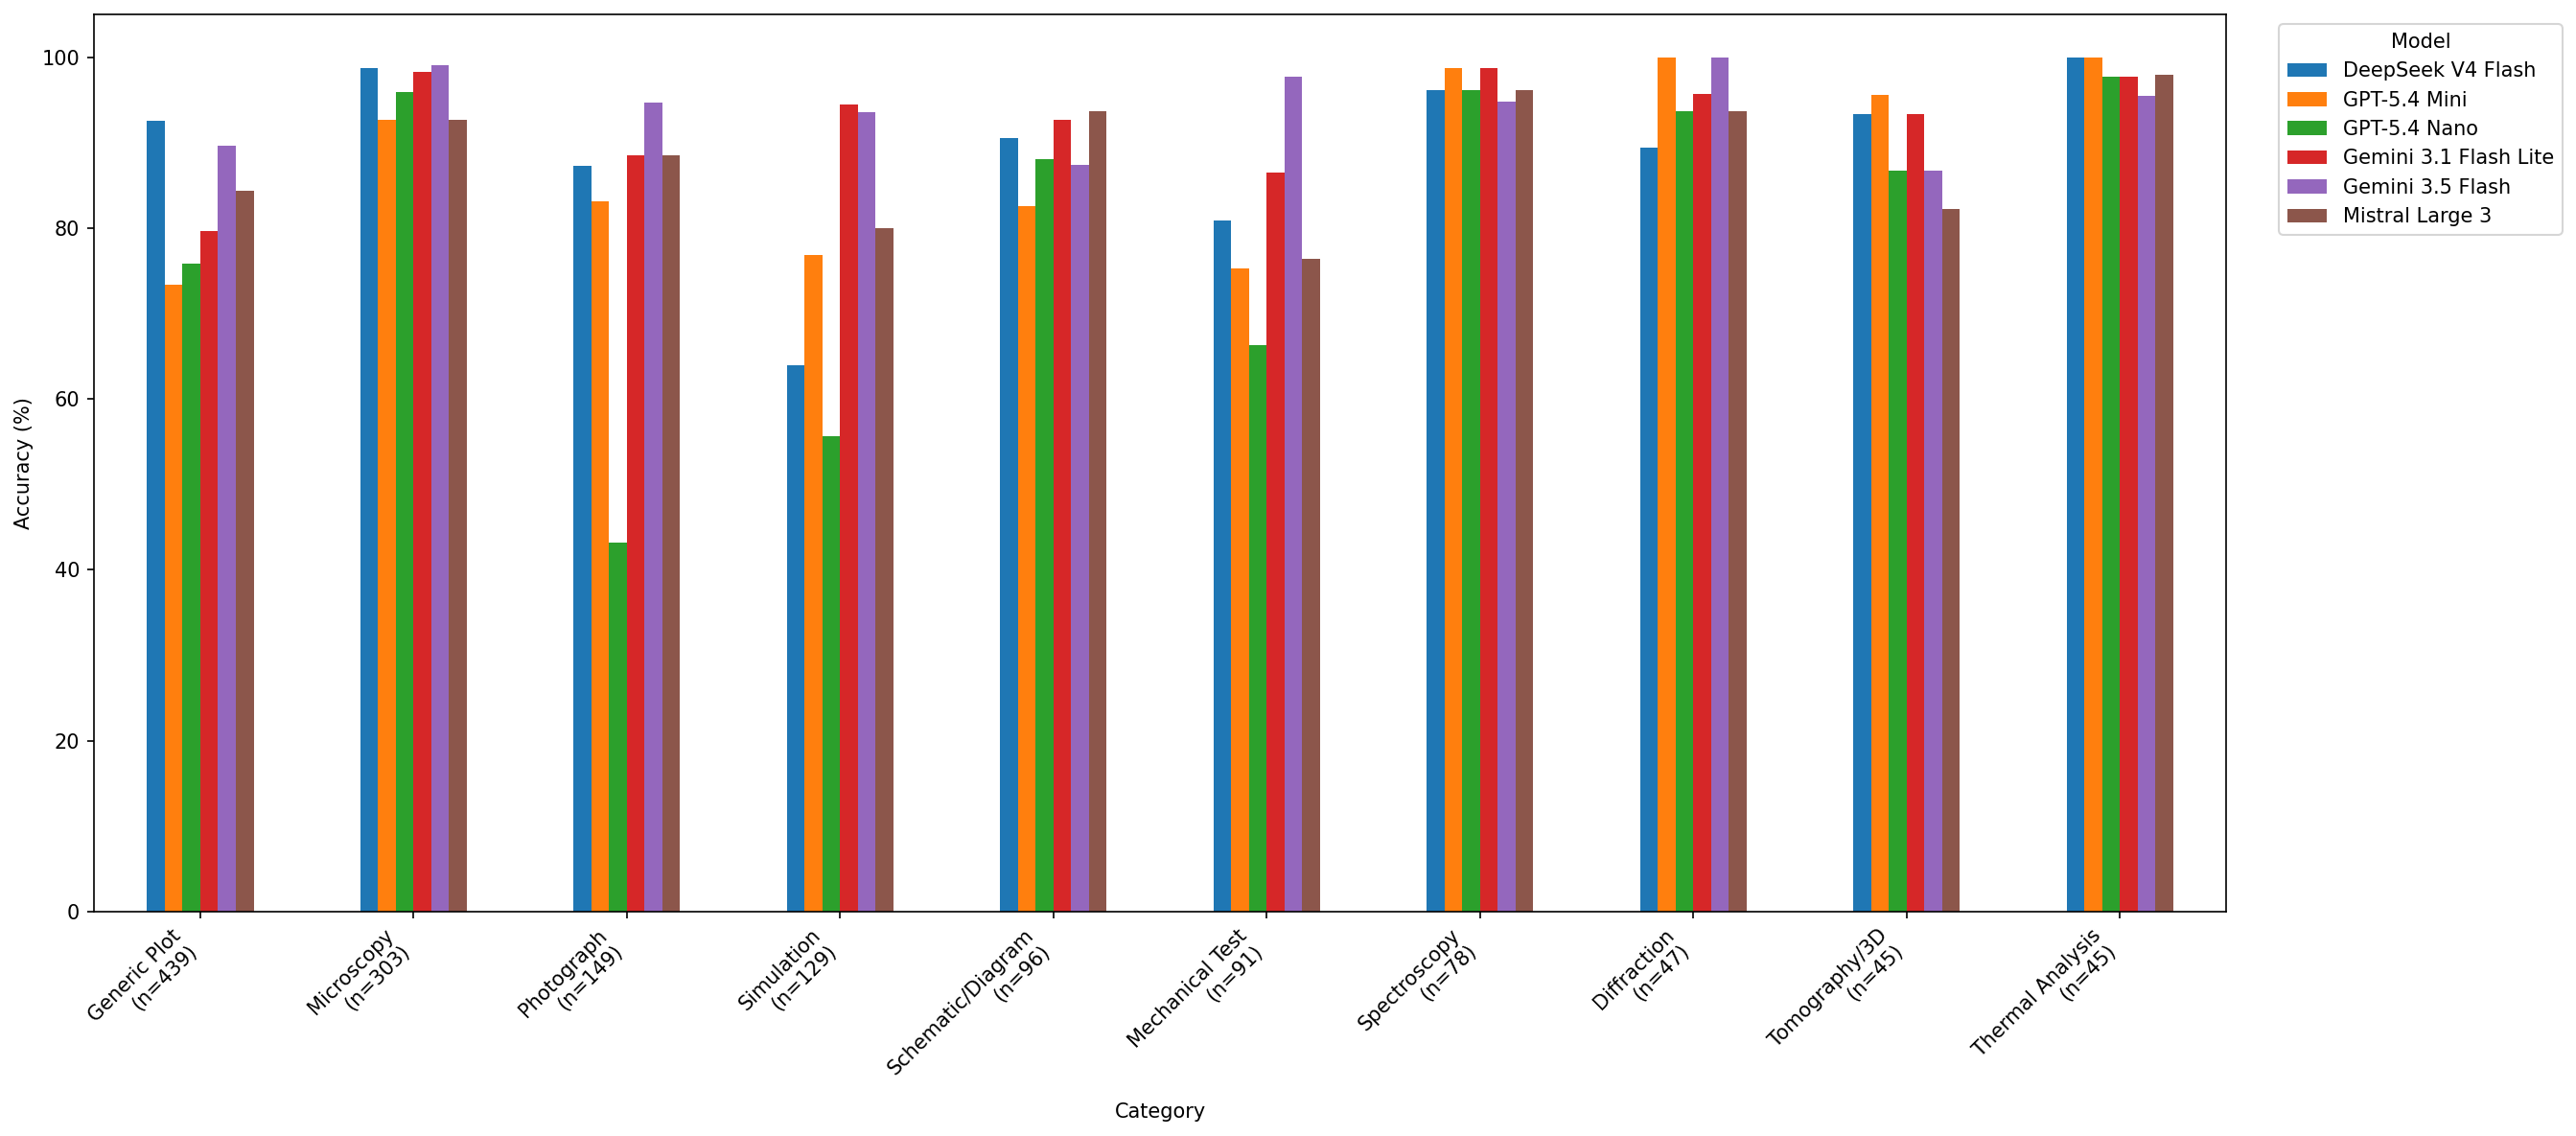

In [25]:
valid_categories = (
    category_counts[category_counts >= 40]
    .sort_values(ascending=False)
    .index
)

category_accuracy_filtered = category_accuracy[valid_categories]
print(category_accuracy_filtered)
labels = [
    f"{cat}\n(n={category_counts[cat]})"
    for cat in category_accuracy_filtered.columns
]

ax = category_accuracy_filtered.T.plot(
    kind="bar",
    figsize=(18,8)
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Category")

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()
plt.show()

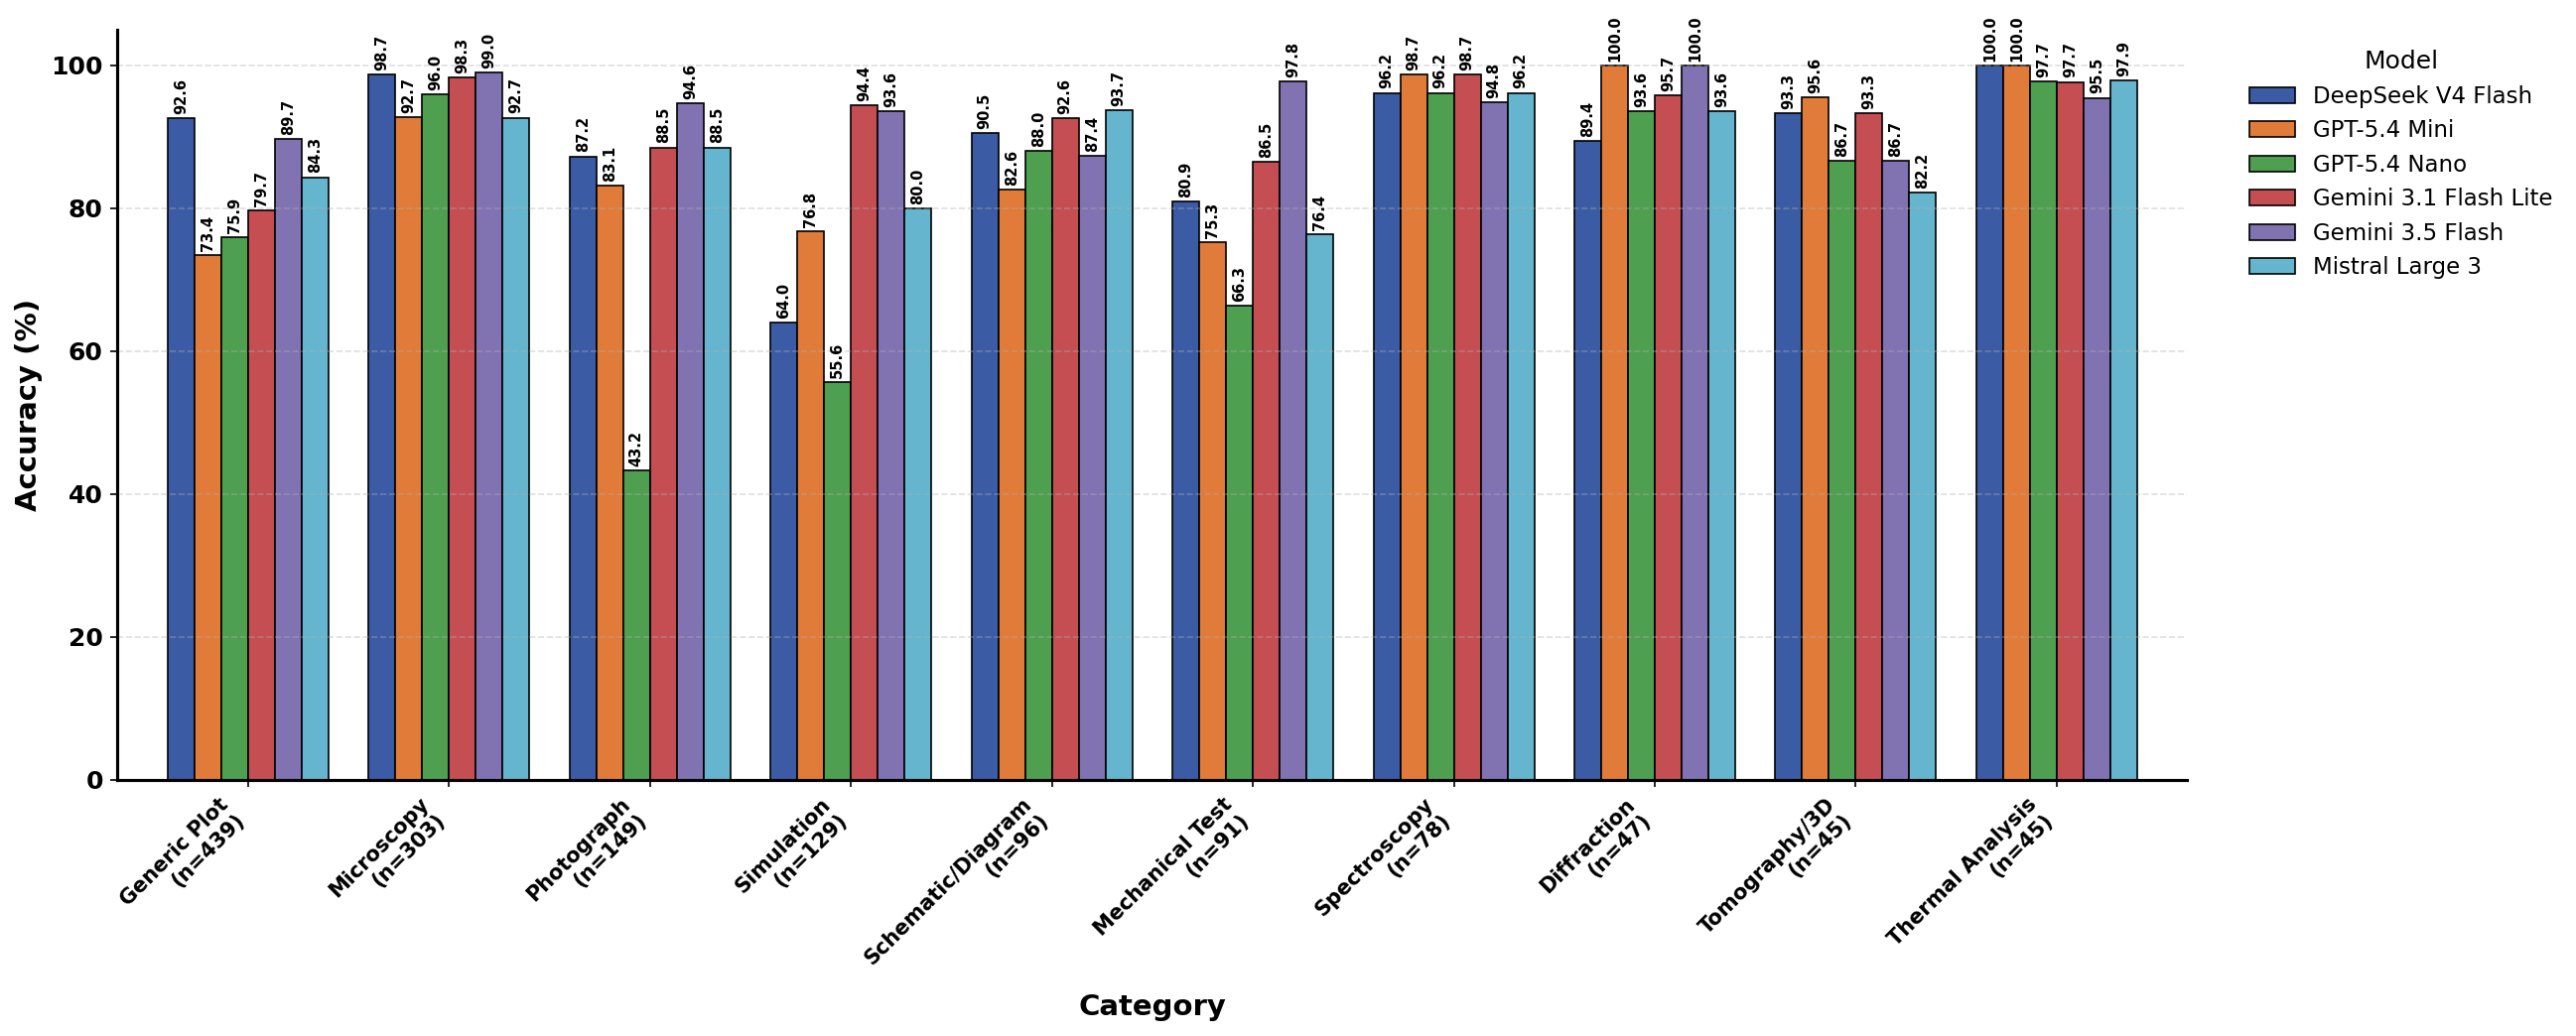

: 

In [ ]:
# Nature/paper-style palette (different from your count plot)

colors = [
    "#3B5BA5",
    "#E07B39",
    "#4E9F50",
    "#C44E52",
    "#8172B2",
    "#64B5CD"
]

# Labels
labels = [
    f"{cat}\n(n={category_counts[cat]})"
    for cat in category_accuracy_filtered.columns
]
ax = category_accuracy_filtered.T.plot(
    kind="bar",
    figsize=(20, 8),
    color=colors[:len(category_accuracy_filtered.index)],
    edgecolor="black",
    linewidth=0.8,
    width=0.8
)

# Axis labels
ax.set_ylabel(
    "Accuracy (%)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Category",
    fontsize=14,
    fontweight="bold"
)

# Custom x-axis labels with sample counts
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

# Bold y-axis tick labels
ax.tick_params(axis='y', labelsize=12)

for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

# Legend styling
legend = ax.legend(
    title="Model",
    fontsize=11,
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Thicker axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Light horizontal grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Accuracy values above bars
for container in ax.containers:
    labels_bar = [
        f"{v:.1f}" if v > 0 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels_bar,
        fontsize=7,
        fontweight='bold',
        rotation=90,
        padding=2
    )

# Leave room for multiline x-labels and legend
plt.subplots_adjust(
    bottom=0.25,
    right=0.82
)

plt.savefig(
    "category_accuracy.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
category_subcategory_accuracy = (
    merged_df
    .dropna(subset=["true_subcategory"])
    .groupby(
        ["model", "true_subcategory"]
    )["subcategory_correct"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

category_subcategory_accuracy

true_subcategory,3D Reconstruction,AFM,Arrhenius Plot,Ashby Plot,BF-TEM,Bar Chart,Box Plot,CALPHAD Diagram,Capacity Retention Plot,Confocal Microscopy,...,Synchrotron Diffraction,TEM,TGA Curve,Ternary Phase Diagram,Transmittance Spectrum,UV-Vis Spectrum,XPS Spectrum,XRD Pattern,other,t-SNE/UMAP/PCA Plot
model,,,,,,,,,,,,,,,,,,,,,
DeepSeek V4 Flash,54.55,100.0,100.0,100.0,66.67,94.59,100.0,0.0,0.0,100.0,...,40.0,94.44,100.0,0.0,100.0,100.0,100.0,100.0,0.0,100.0
GPT-5.4 Mini,63.64,100.0,100.0,100.0,66.67,50.0,100.0,100.0,0.0,100.0,...,100.0,94.44,100.0,66.67,100.0,50.0,100.0,100.0,0.0,100.0
GPT-5.4 Nano,81.82,100.0,100.0,100.0,100.0,43.75,100.0,100.0,0.0,100.0,...,100.0,83.33,100.0,0.0,100.0,100.0,100.0,100.0,0.0,100.0
Gemini 3.1 Flash Lite,63.64,100.0,100.0,100.0,66.67,72.07,100.0,0.0,100.0,100.0,...,100.0,94.44,100.0,100.0,100.0,50.0,100.0,100.0,100.0,100.0
Gemini 3.5 Flash,81.82,100.0,100.0,100.0,66.67,82.14,100.0,50.0,100.0,100.0,...,100.0,94.44,100.0,100.0,0.0,50.0,100.0,100.0,100.0,100.0
Mistral Large 3,60.0,100.0,100.0,100.0,66.67,76.58,100.0,100.0,100.0,100.0,...,40.0,66.67,100.0,66.67,100.0,0.0,100.0,100.0,0.0,66.67


In [ ]:
subcategory_counts = (
    truth_df["true_subcategory"]
    .value_counts()
)

subcategory_counts.head(20)
min_count = 20

valid_subcategories = (
    subcategory_counts[subcategory_counts >= min_count]
    .sort_values(ascending=False)
    .index
)

subcategory_accuracy_filtered = category_subcategory_accuracy[
    valid_subcategories
]
subcategory_accuracy_filtered

true_subcategory,Line Graph,SEM,FEA/FEM Result,Sample Photo,Bar Chart,Optical Micrograph,Stress-Strain Curve,Process Schematic,Mechanism Diagram,XPS Spectrum,Micro-CT,DSC Curve,Contour Plot,Scatter Plot,Fatigue/S-N Curve,EDS Map,FTIR Spectrum,In-situ Photo
model,,,,,,,,,,,,,,,,,,
DeepSeek V4 Flash,88.28,99.1,65.85,87.29,94.59,96.08,84.78,87.5,80.49,100.0,100.0,100.0,85.71,75.0,84.62,100.0,100.0,71.43
GPT-5.4 Mini,70.82,98.2,74.8,84.75,50.0,68.63,91.3,83.78,68.29,100.0,100.0,97.06,92.86,50.0,42.31,86.96,100.0,66.67
GPT-5.4 Nano,81.22,98.19,55.74,32.2,43.75,93.75,71.74,91.67,78.05,100.0,83.33,76.47,85.71,33.33,11.54,100.0,100.0,71.43
Gemini 3.1 Flash Lite,76.96,100.0,97.56,88.98,72.07,90.2,91.3,90.0,90.24,100.0,97.22,100.0,85.71,45.83,73.08,95.65,100.0,61.9
Gemini 3.5 Flash,89.12,99.55,93.5,92.44,82.14,96.08,100.0,85.0,82.93,100.0,88.89,100.0,64.29,81.48,100.0,100.0,100.0,95.24
Mistral Large 3,70.29,100.0,81.3,85.34,76.58,62.75,73.91,92.5,92.5,100.0,83.33,65.79,92.59,70.37,53.85,100.0,100.0,90.48


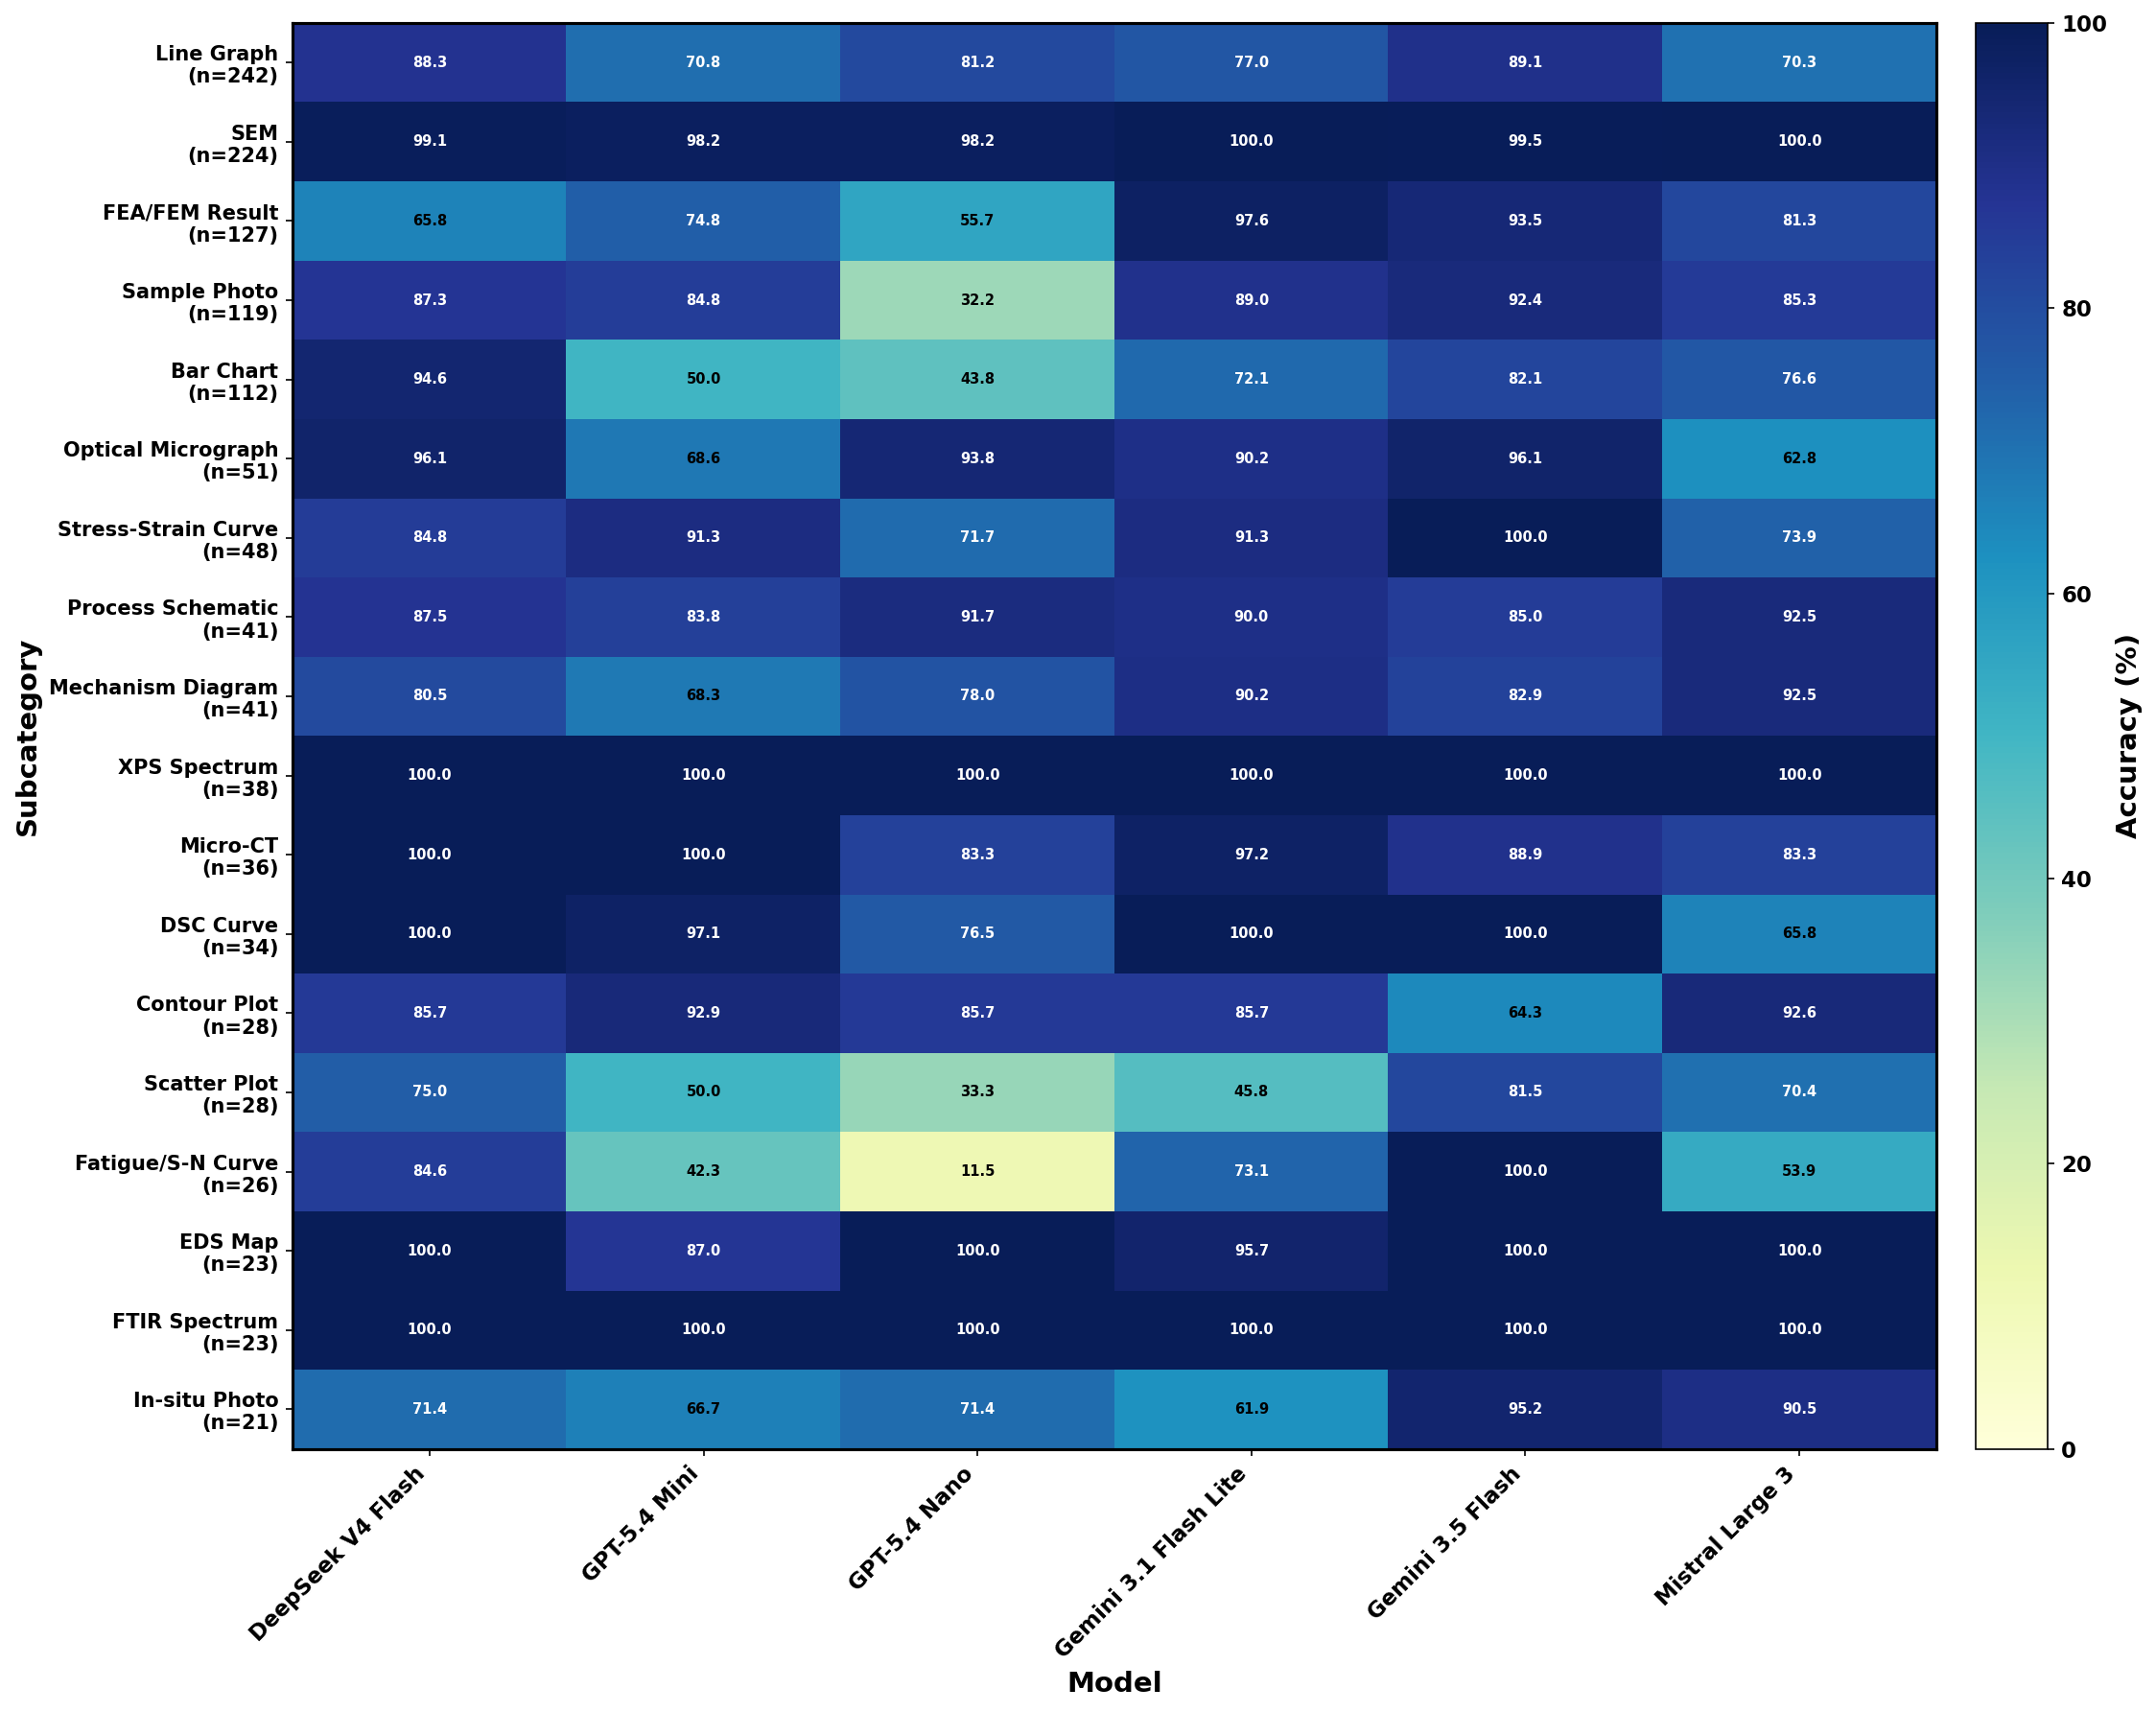

In [ ]:
# Count samples per subcategory
subcategory_counts = (
    truth_df["true_subcategory"]
    .value_counts()
)

min_count = 20

valid_subcategories = (
    subcategory_counts[subcategory_counts >= min_count]
    .sort_values(ascending=False)
    .index
)

subcategory_accuracy_filtered = category_subcategory_accuracy[
    valid_subcategories
]


# Labels with sample counts
labels = [
    f"{s}\n(n={subcategory_counts[s]})"
    for s in subcategory_accuracy_filtered.columns
]

fig, ax = plt.subplots(figsize=(16, 12))

# Heatmap
im = ax.imshow(
    subcategory_accuracy_filtered.T.to_numpy(dtype=float),
    aspect="auto",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    interpolation="nearest"
)
# Colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Accuracy (%)",
    fontsize=14,
    fontweight="bold"
)

cbar.ax.tick_params(labelsize=11)

for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

# X-axis (models)
ax.set_xticks(range(len(subcategory_accuracy_filtered.index)))
ax.set_xticklabels(
    subcategory_accuracy_filtered.index,
    rotation=45,
    ha="right",
    fontsize=11,
    fontweight="bold"
)

# Y-axis (subcategories)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(
    labels,
    fontsize=10,
    fontweight="bold"
)

# Axis labels
ax.set_xlabel(
    "Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Subcategory",
    fontsize=14,
    fontweight="bold"
)

# Optional title
'''ax.set_title(
    "Subcategory Accuracy Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)'''

# Thicker border around heatmap
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Add accuracy values inside cells
for i in range(subcategory_accuracy_filtered.shape[0]):  # models
    for j in range(subcategory_accuracy_filtered.shape[1]):  # subcategories

        value = subcategory_accuracy_filtered.iloc[i, j]

        ax.text(
            i,
            j,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color="black" if value < 70 else "white"
        )

plt.tight_layout()

plt.savefig(
    "subcategory_accuracy_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import json
import os
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = 'gemini_3.5_flash_outputs'

## Load all JSON files

In [ ]:
records = []
errors = []

for fname in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, fname)
    try:
        data = json.load(open(path))
        if 'panels' not in data:
            errors.append(fname)
            continue
        for p in data['panels']:
            records.append({
                'file':               fname,
                'panel':              p.get('panel', ''),
                'visualization_category': p.get('visualization_category', 'missing'),
                'visualization_type': p.get('visualization_subtype', 'missing'),
                'subcaption':         p.get('subcaption', ''),
                'summary':            p.get('summary', ''),
                'subcaption_words':   len(p.get('subcaption', '').split()),
                'summary_words':      len(p.get('summary', '').split()),
            })
    except Exception as e:
        errors.append(fname)

df = pd.DataFrame(records)
print(f'Total files   : {len(os.listdir(OUTPUT_DIR))}')
print(f'Total panels  : {len(df)}')
print(f'Error files   : {len(errors)}')
df.head()

Total files   : 430
Total panels  : 2300
Error files   : 10


,file,panel,visualization_category,visualization_type,subcaption,summary,subcaption_words,summary_words
0,steel_img100.json,A,Generic Plot,Line Graph,Temperature profile as a function of time (sec...,This line graph displays the temperature profi...,38,33
1,steel_img100.json,B,Generic Plot,Line Graph,Detailed temperature versus time profile for a...,This detailed temperature-time profile focuses...,62,40
2,steel_img1004.json,a,Thermal Analysis,TGA Curve,Thermogravimetric analysis (TGA) thermograms s...,TGA thermograms plot weight variation (%) agai...,30,34
3,steel_img1004.json,b,Generic Plot,Bar Chart,Bar chart displaying the onset degradation tem...,This bar chart displays the onset degradation ...,79,39
4,steel_img1004.json,c,Thermal Analysis,DSC Curve,Differential scanning calorimetry (DSC) thermo...,DSC thermograms plot heat flow (W/g) against t...,37,34


## Visualization Type — Value Counts

In [ ]:
vc = df['visualization_type'].value_counts()
print(vc.to_string())

visualization_type
Line Graph                    380
SEM                           346
FEA/FEM Result                217
Bar Chart                     180
Sample Photo                  157
Optical Micrograph             90
Stress-Strain Curve            67
Mechanism Diagram              59
Process Schematic              57
In-situ Photo                  52
Scatter Plot                   47
Confocal Microscopy            42
EDS Map                        40
XPS Spectrum                   39
Micro-CT                       37
DSC Curve                      34
Contour Plot                   33
EBSD Map                       31
Fluorescence Microscopy        31
Fatigue/S-N Curve              26
3D Reconstruction              24
Live/Dead Staining             23
TEM                            19
Experimental Setup             17
Phase-Field Simulation         15
Histogram                      15
FTIR Spectrum                  14
EDX Spectrum                   13
other                        

In [ ]:
print(df['panel'].value_counts().to_string())

panel
a       319
b       319
c       317
d       311
e       177
f       140
A        75
B        74
C        74
D        74
g        70
h        47
E        46
F        39
G        29
H        26
main     25
i        23
I        19
J        14
K        13
j        11
L        11
k         8
l         7
M         5
N         5
O         4
m         3
n         3
P         3
o         2
B-i       1
B-ii      1
p         1
q         1
r         1
s         1
t         1


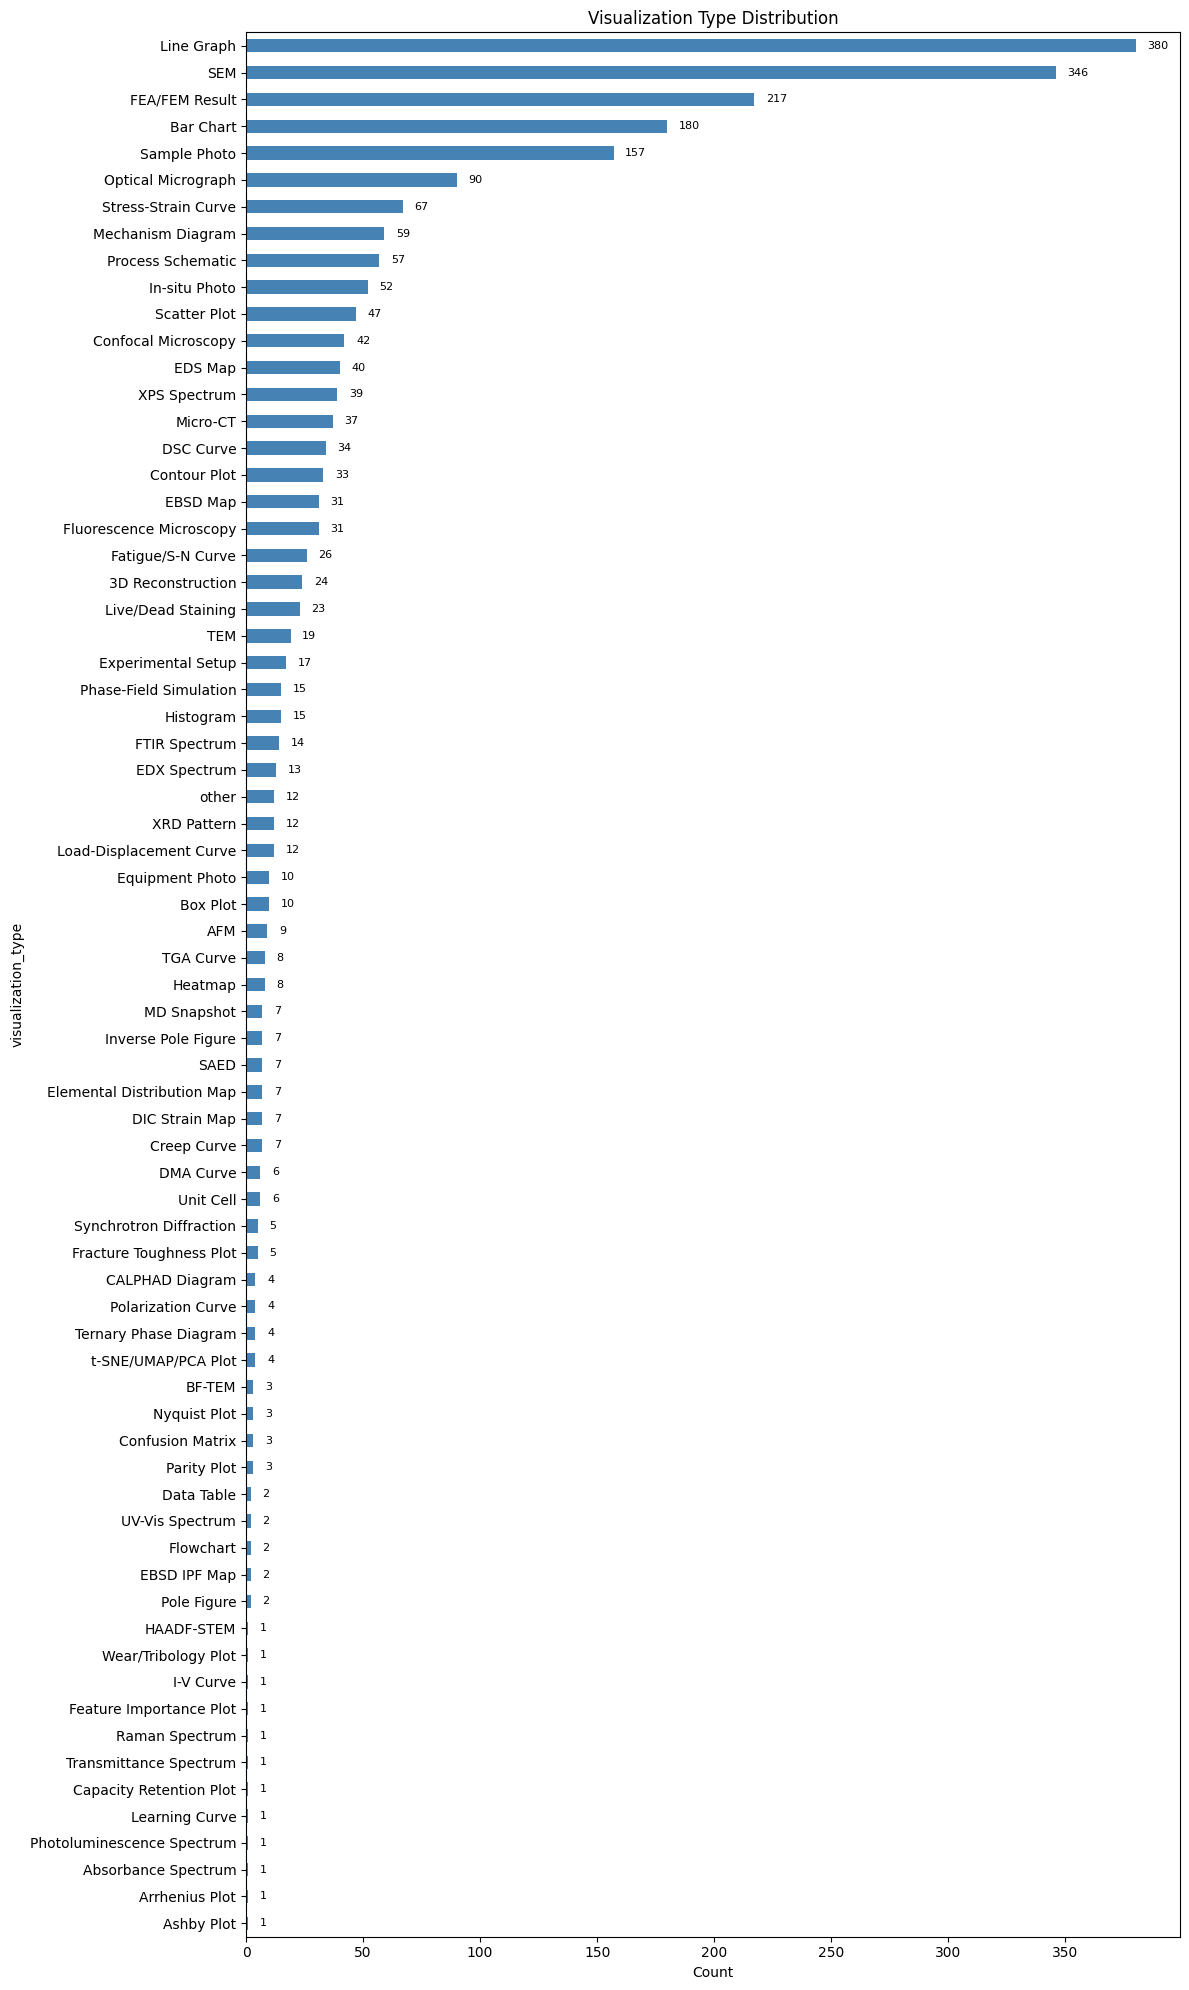

In [ ]:
fig, ax = plt.subplots(figsize=(12, 20))
vc.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Count')
ax.set_title('Visualization Type Distribution')
for i, v in enumerate(vc):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Panels per Figure

panel
1      25
2       3
3       7
4     161
5      45
6      81
7      26
8      30
9      17
10      4
11      4
12      9
14      2
15      2
16      3
20      1


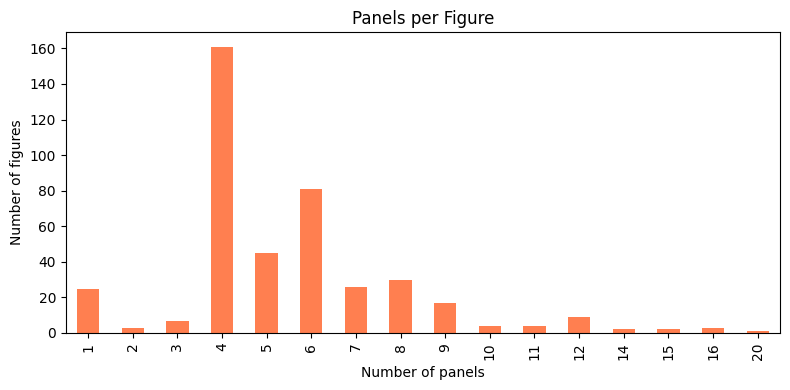

In [ ]:
panels_per_fig = df.groupby('file')['panel'].count()
print(panels_per_fig.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
panels_per_fig.value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Number of panels')
ax.set_ylabel('Number of figures')
ax.set_title('Panels per Figure')
plt.tight_layout()
plt.show()

## Subcaption & Summary Word Count Distribution

In [ ]:
print('Subcaption word count:')
print(df['subcaption_words'].describe().round(1))
print()
print('Summary word count:')
print(df['summary_words'].describe().round(1))

Subcaption word count:
count    2300.0
mean       30.4
std        11.5
min         9.0
25%        22.0
50%        28.0
75%        38.0
max        94.0
Name: subcaption_words, dtype: float64

Summary word count:
count    2300.0
mean       35.7
std         6.0
min        12.0
25%        32.0
50%        36.0
75%        40.0
max        63.0
Name: summary_words, dtype: float64


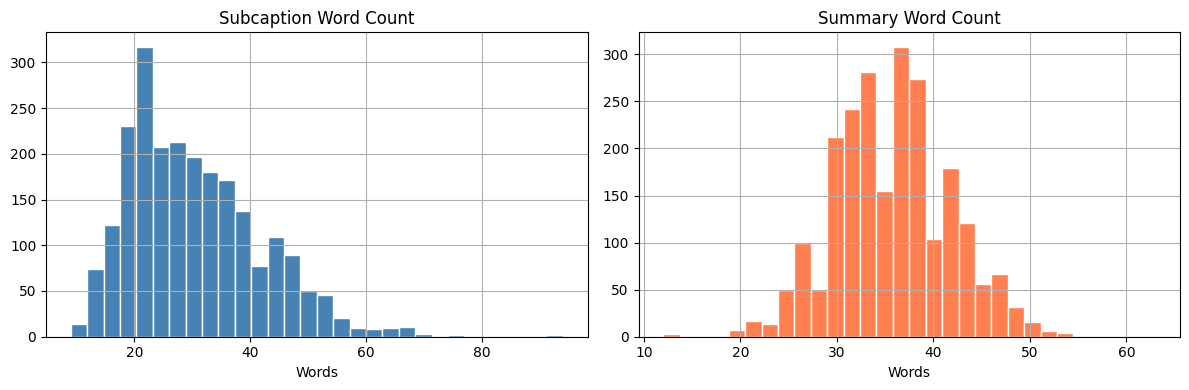

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['subcaption_words'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Subcaption Word Count')
axes[0].set_xlabel('Words')

df['summary_words'].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Summary Word Count')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

## Avg Word Count by Visualization Type

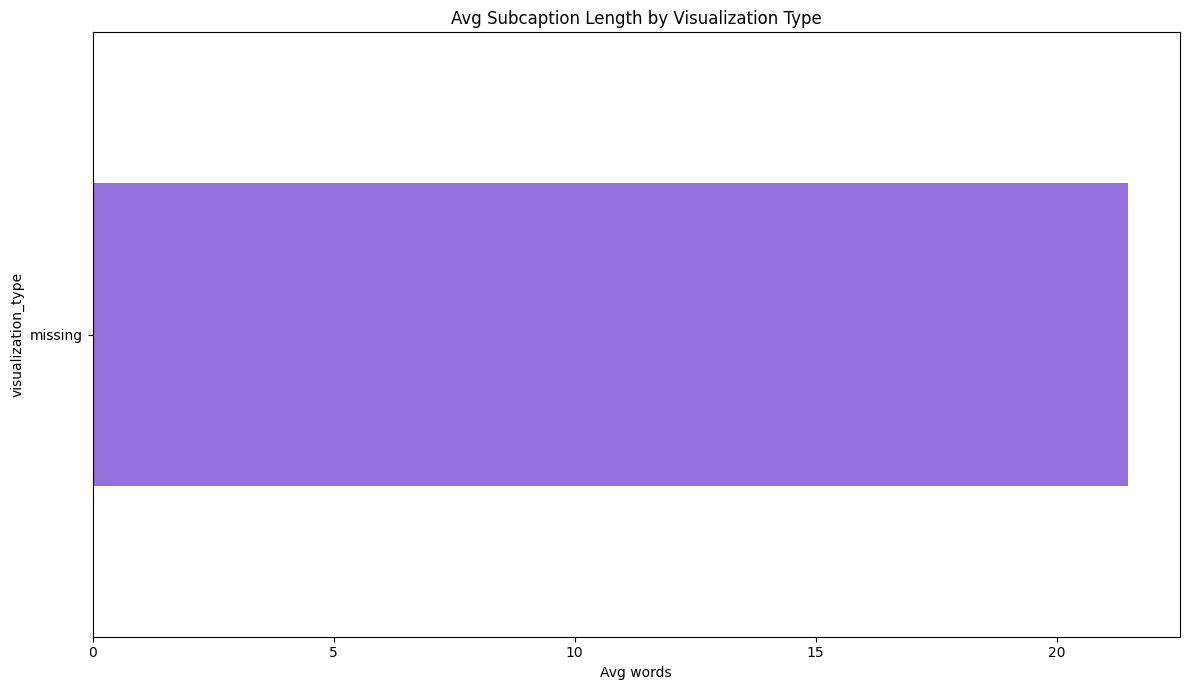

In [ ]:
avg_words = df.groupby('visualization_type')['subcaption_words'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
avg_words.plot(kind='barh', ax=ax, color='mediumpurple')
ax.invert_yaxis()
ax.set_xlabel('Avg words')
ax.set_title('Avg Subcaption Length by Visualization Type')
plt.tight_layout()
plt.show()

## 'other' Type — NLP Analysis

In [ ]:
print("Sample 'Line Graph' subcaptions:\n")
other_df = df[df['visualization_type'] == 'Line Graph'].copy()

print("Sample 'Line Graph' subcaptions:\n")
if other_df.empty:
    print("No 'Line Graph' panels found.")
else:
    for _, row in other_df.sample(min(10, len(other_df)), random_state=42).iterrows():
        print(f"{row['file']} [{row['panel']}]")
        print(f"  {row['subcaption']}")
        print()

Sample 'Line Graph' subcaptions:

Sample 'Line Graph' subcaptions:

No 'Line Graph' panels found.


ValueError: empty vocabulary; perhaps the documents only contain stop words

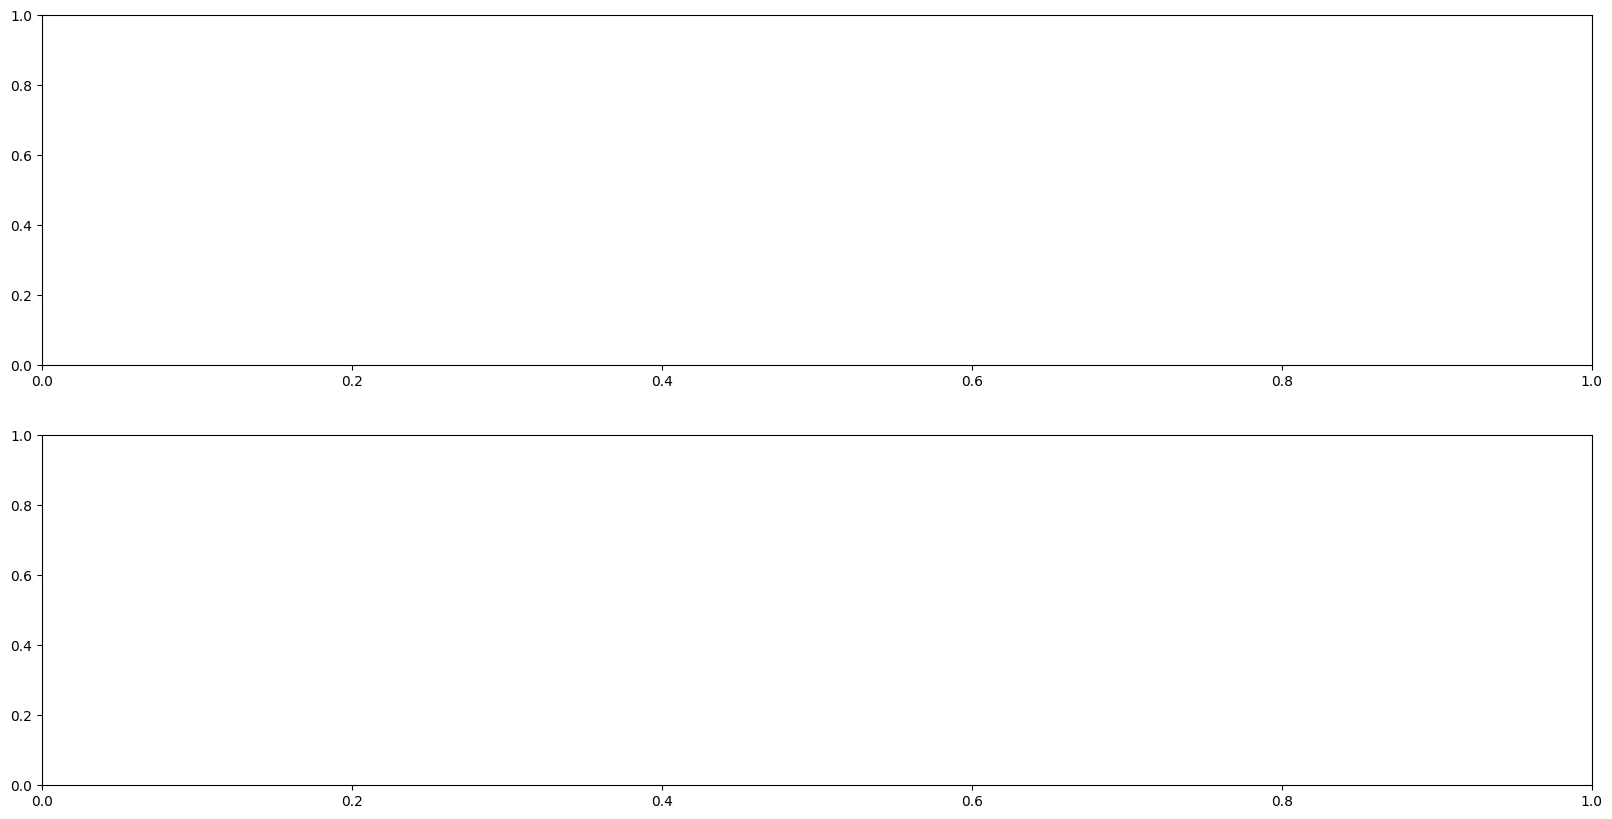

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(2, 1, figsize=(20,10 ))

# Top unigrams
vec1 = CountVectorizer(stop_words='english', ngram_range=(1, 1), max_features=30)
X1 = vec1.fit_transform(other_df['subcaption'])
uni = pd.Series(X1.toarray().sum(axis=0), index=vec1.get_feature_names_out()).sort_values(ascending=False)
uni.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Top 30 Words — 'other'")
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)

# Top bigrams
vec2 = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=30)
X2 = vec2.fit_transform(other_df['subcaption'])
bi = pd.Series(X2.toarray().sum(axis=0), index=vec2.get_feature_names_out()).sort_values(ascending=False)
bi.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Top 30 Bigrams — 'other'")
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

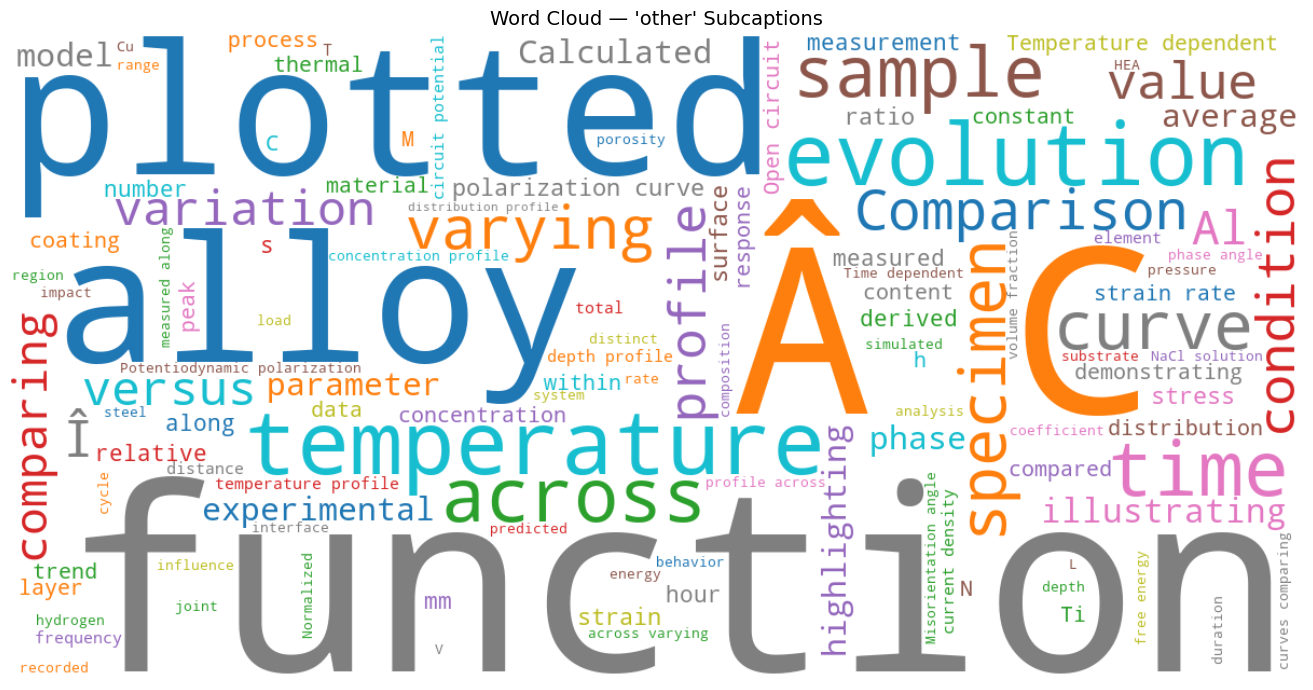

In [ ]:
from wordcloud import STOPWORDS

all_text = ' '.join(other_df['subcaption'].tolist())

stopwords = set(STOPWORDS) | {
    'figure', 'panel', 'image', 'shows', 'shown', 'showing',
    'used', 'using', 'based', 'also', 'two', 'one', 'three',
    'corresponding', 'respective', 'different', 'various'
}

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    stopwords=stopwords,
    max_words=120,
    colormap='tab10',
).generate(all_text)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title("Word Cloud — 'other' Subcaptions", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

other_df = df[df['visualization_type'] == 'other'].copy()
print(f"'other' panels : {len(other_df)}")
other_df[['file', 'panel', 'subcaption']].head(10)

'other' panels : 1466


,file,panel,subcaption
2,img100.json,a,Atom probe tomography reconstruction of a 41Â°...
3,img100.json,b,Chromium isocomposition surfaces within the sa...
26,img10008.json,c,Computed tomography reconstruction of an untre...
27,img10008.json,d,Computed tomography reconstruction of an AA608...
130,img10041.json,a,ESPI fringe pattern and comparative displaceme...
131,img10041.json,b,Displacement maps obtained via ESPI and DIC at...
133,img10042.json,b,Speckle fringe patterns representing the evolu...
134,img10042.json,c,Visualization of shear band propagation within...
137,img10044.json,a,Comparison of Gaussian-filtered fringe images ...
138,img10044.json,b,Fringe images for Î¾x and Î¾y directions at Îµ...


## Error Files

In [ ]:
print(f'Files with errors: {len(errors)}')
for f in errors:
    print(' ', f)